In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# File paths
SAPS_PATH = '/Users/robert/Desktop/DCU/SEM 2/CSC1144 Data Analytics & Data Mining/PROJECT/INITIAL DATASETS/SAPS_2022_Small_Area_UR_171024.csv'
BER_PATH = '/Users/robert/Desktop/DCU/SEM 2/CSC1144 Data Analytics & Data Mining/PROJECT/INITIAL DATASETS/BER Public Search/BERPublicsearch.txt'
GEOJSON_PATH = '/Users/robert/Desktop/DCU/SEM 2/CSC1144 Data Analytics & Data Mining/PROJECT/INITIAL DATASETS/SMALL_AREA_2022_Genralised_20m_view_-4176251332041431098.geojson'

print("Libraries loaded. Ready to import data.")

Libraries loaded. Ready to import data.


In [2]:
# Load GeoJSON (spatial boundaries)
# File has stray leading 'x' character — strip before loading
import io

with open(GEOJSON_PATH, 'r', encoding='utf-8') as f:
    content = f.read().lstrip('x')

gdf_boundaries = gpd.read_file(io.StringIO(content))

print("=" * 60)
print("BOUNDARIES LOADED")
print(f"Shape: {gdf_boundaries.shape}")
print(f"CRS: {gdf_boundaries.crs}")
print(f"\nFirst 3 rows:")
print(gdf_boundaries[['SA_GUID_2022', 'SA_PUB2022', 'COUNTY_ENGLISH', 'SA_URBAN_AREA_FLAG']].head(3))
print(f"\nColumn names:")
print(gdf_boundaries.columns.tolist())

BOUNDARIES LOADED
Shape: (18919, 27)
CRS: EPSG:4326

First 3 rows:
                           SA_GUID_2022 SA_PUB2022 COUNTY_ENGLISH  \
0  4c07d11e-2c46-851d-e053-ca3ca8c0ca7f  147005003          LOUTH   
1  4c07d11e-1d31-851d-e053-ca3ca8c0ca7f  247091008        WEXFORD   
2  4c07d11d-fae7-851d-e053-ca3ca8c0ca7f  057103001        DONEGAL   

   SA_URBAN_AREA_FLAG  
0                   1  
1                   1  
2                   0  

Column names:
['OBJECTID', 'SA_GUID_2016', 'SA_GUID_2022', 'SA_PUB2011', 'SA_PUB2016', 'SA_PUB2022', 'SA_GEOGID_2022', 'SA_CHANGE_CODE', 'SA_URBAN_AREA_FLAG', 'SA_URBAN_AREA_NAME', 'SA_NUTS1', 'SA_NUTS1_NAME', 'SA_NUTS2', 'SA_NUTS2_NAME', 'SA_NUTS3', 'SA_NUTS3_NAME', 'ED_GUID', 'ED_OFFICIAL', 'ED_ENGLISH', 'ED_GAEILGE', 'ED_ID_STR', 'ED_PART_COUNT', 'COUNTY_CODE', 'COUNTY_ENGLISH', 'COUNTY_GAEILGE', 'CSO_LEA', 'geometry']


In [3]:
# Cell 3: Load SAPS Census 2022 data — exploration only
# Filter IE0 national totals row before any analysis

saps = pd.read_csv(SAPS_PATH)
saps = saps[saps['GUID'] != 'IE0'].copy()  # Remove national totals row

print("=" * 60)
print("SAPS DATA LOADED")
print(f"Shape: {saps.shape}")
print(f"Total Small Areas: {len(saps):,}")
print(f"\nKey columns available:")

key_cols = [
    'GUID', 'T5_1T_H', 'T8_1_STUM', 'T8_1_LTUM',
    'T8_1_STUF', 'T8_1_LTUF', 'T1_1AGETM', 'T1_1AGETF',
    'T15_1_NC', 'T15_1_TC', 'T6_2_PRE19H', 'T6_2_TH'
]
missing = [c for c in key_cols if c not in saps.columns]
found = [c for c in key_cols if c in saps.columns]
print(f"Found: {found}")
print(f"Missing: {missing}")

print(f"\nSample — Total Households (T5_1T_H):")
print(saps['T5_1T_H'].describe().round(3))

SAPS DATA LOADED
Shape: (18919, 795)
Total Small Areas: 18,919

Key columns available:
Found: ['GUID', 'T5_1T_H', 'T8_1_STUM', 'T8_1_LTUM', 'T8_1_STUF', 'T8_1_LTUF', 'T1_1AGETM', 'T1_1AGETF', 'T15_1_NC', 'T15_1_TC', 'T6_2_PRE19H', 'T6_2_TH']
Missing: []

Sample — Total Households (T5_1T_H):
count    18919.000
mean        97.318
std         26.825
min          0.000
25%         79.000
50%         94.000
75%        113.000
max        390.000
Name: T5_1T_H, dtype: float64


In [5]:
# Cell 4: Load BER database — chunked load to handle corrupted rows
# on_bad_lines='warn' recovers all valid records without crashing

ber_cols_needed = [
    'SA_Code', 'EnergyRating', 'CO2Rating',
    'GroundFloorArea(sq m)', 'UValueWall',
    'DeliveredEnergyMainSpace', 'TotalDeliveredEnergy'
]

chunks = []
for chunk in pd.read_csv(
    BER_PATH,
    sep='\t',
    encoding='latin-1',
    on_bad_lines='warn',
    usecols=ber_cols_needed,
    chunksize=100_000,
    low_memory=False
):
    chunks.append(chunk)

ber_raw = pd.concat(chunks, ignore_index=True)

print("=" * 60)
print("BER DATA LOADED")
print(f"Total records: {len(ber_raw):,}")
print(f"Null SA_Code: {ber_raw['SA_Code'].isnull().sum():,}")
print(f"Valid SA_Code: {ber_raw['SA_Code'].notna().sum():,}")
print(f"\nEnergy Rating distribution (top 10):")
print(ber_raw['EnergyRating'].value_counts().head(10))

BER DATA LOADED
Total records: 1,346,555
Null SA_Code: 327,725
Valid SA_Code: 1,018,830

Energy Rating distribution (top 10):
EnergyRating
A2    157097
C2    142899
C1    138667
C3    129621
D1    120752
B3    118311
D2    102595
A3     85444
G      72423
B2     65572
Name: count, dtype: int64


In [6]:
# Cell 5: SA_Code cleaning and BER aggregation to Small Area level
# zfill(9) standardises code length, split '/' recovers multi-SA records

ber_clean = ber_raw.dropna(subset=['SA_Code']).copy()

def clean_sa_code(code):
    code = str(code).strip()
    if '/' in code:
        code = code.split('/')[0].strip()
    try:
        return str(int(float(code))).zfill(9)
    except:
        return None

ber_clean['SA_Code'] = ber_clean['SA_Code'].apply(clean_sa_code)
ber_clean = ber_clean.dropna(subset=['SA_Code'])
ber_clean = ber_clean[ber_clean['SA_Code'].str.len() == 9]
ber_clean = ber_clean.rename(columns={'GroundFloorArea(sq m)': 'GroundFloorArea'})

print(f"Records after cleaning: {len(ber_clean):,}")
print(f"Unique Small Areas covered: {ber_clean['SA_Code'].nunique():,}")

# Aggregate to Small Area level — mean for continuous, mode for rating
ber_agg = ber_clean.groupby('SA_Code').agg(
    property_count=('EnergyRating', 'count'),
    EnergyRating=('EnergyRating', lambda x: x.mode()[0] if len(x) > 0 else None),
    CO2Rating=('CO2Rating', 'mean'),
    GroundFloorArea=('GroundFloorArea', 'mean'),
    UValueWall=('UValueWall', 'mean'),
    DeliveredEnergyMainSpace=('DeliveredEnergyMainSpace', 'mean'),
    TotalDeliveredEnergy=('TotalDeliveredEnergy', 'mean')
).reset_index()

print(f"\nSmall Areas with BER data: {len(ber_agg):,}")
print(f"Small Areas without BER data: {18919 - len(ber_agg):,}")
print(f"BER coverage: {len(ber_agg)/18919*100:.1f}%")
print(f"\nSample aggregated BER data:")
print(ber_agg.head(3).round(3))

Records after cleaning: 1,018,830
Unique Small Areas covered: 18,444

Small Areas with BER data: 18,444
Small Areas without BER data: 475
BER coverage: 97.5%

Sample aggregated BER data:
     SA_Code  property_count EnergyRating  CO2Rating  GroundFloorArea  \
0  000000000               1           A2      5.630           99.280   
1  017001001              47           B2     56.408          179.908   
2  017002001              31           B3     50.455          191.713   

   UValueWall  DeliveredEnergyMainSpace  TotalDeliveredEnergy  
0       0.160                  4024.149                   NaN  
1       0.632                 18094.750             30611.544  
2       0.557                 19438.691             32728.276  


In [7]:
# Cell 6: Merge BER aggregated data onto boundary GeoDataFrame
# Left join preserves all 18,919 Small Areas including those without BER data

gdf_boundaries['SA_PUB2022_9'] = gdf_boundaries['SA_PUB2022'].astype(str).str.zfill(9)

gdf_merged = gdf_boundaries.merge(
    ber_agg,
    left_on='SA_PUB2022_9',
    right_on='SA_Code',
    how='left'
)

print("=" * 60)
print("MERGE COMPLETE")
print(f"Total Small Areas: {len(gdf_merged):,}")
print(f"With BER data: {gdf_merged['property_count'].notna().sum():,} ({gdf_merged['property_count'].notna().sum()/len(gdf_merged)*100:.1f}%)")
print(f"Without BER data: {gdf_merged['property_count'].isna().sum():,} ({gdf_merged['property_count'].isna().sum()/len(gdf_merged)*100:.1f}%)")
print(f"\nUrban/Rural split:")
print(gdf_merged['SA_URBAN_AREA_FLAG'].map({1:'Urban', 0:'Rural'}).value_counts())
print(f"\nTop 10 counties by Small Area count:")
print(gdf_merged['COUNTY_ENGLISH'].value_counts().head(10))

MERGE COMPLETE
Total Small Areas: 18,919
With BER data: 16,827 (88.9%)
Without BER data: 2,092 (11.1%)

Urban/Rural split:
SA_URBAN_AREA_FLAG
Urban    13185
Rural     5734
Name: count, dtype: int64

Top 10 counties by Small Area count:
COUNTY_ENGLISH
DUBLIN CITY               2261
CORK                      1357
FINGAL                    1035
SOUTH DUBLIN               976
CORK CITY                  849
KILDARE                    807
DUN LAOGHAIRE/RATHDOWN     804
GALWAY                     736
DONEGAL                    720
KERRY                      692
Name: count, dtype: int64


# **7: EDA Visualisations**
### Three simple graphs presenting the dataset clearly
### Professor requirement: minimal, easy to understand

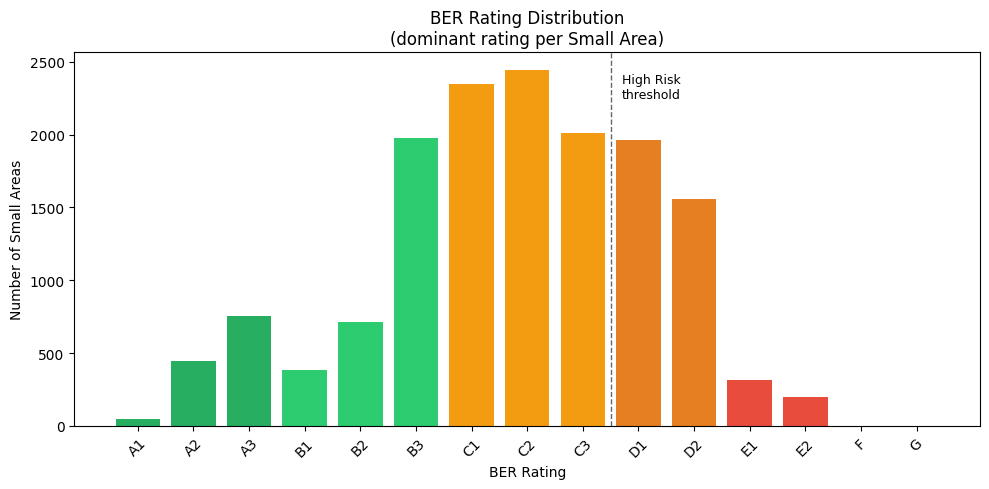

Saved: eda_01_ber_distribution.png


In [9]:
# EDA Graph 1 — BER Rating Distribution
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ber_order = ['A1','A2','A3','B1','B2','B3','C1','C2','C3',
             'D1','D2','E1','E2','F','G']
ber_counts = gdf_merged['EnergyRating'].value_counts().reindex(ber_order).fillna(0)

bar_colors = []
for r in ber_order:
    if r.startswith('A'):   bar_colors.append('#27ae60')
    elif r.startswith('B'): bar_colors.append('#2ecc71')
    elif r.startswith('C'): bar_colors.append('#f39c12')
    elif r.startswith('D'): bar_colors.append('#e67e22')
    elif r.startswith('E'): bar_colors.append('#e74c3c')
    else:                   bar_colors.append('#c0392b')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ber_order, ber_counts, color=bar_colors, edgecolor='none')
ax.axvline(x=8.5, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.text(8.7, ber_counts.max() * 0.92, 'High Risk\nthreshold', fontsize=9)
ax.set_title('BER Rating Distribution\n(dominant rating per Small Area)', fontsize=12)
ax.set_xlabel('BER Rating')
ax.set_ylabel('Number of Small Areas')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_01_ber_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_01_ber_distribution.png')

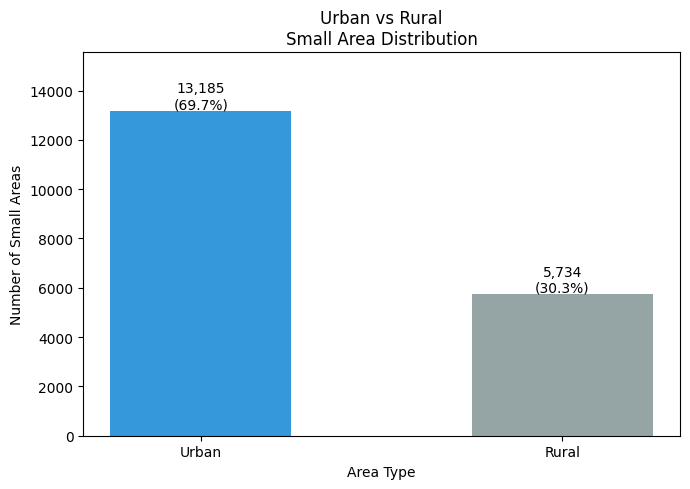

Saved: eda_02_urban_rural.png


In [10]:
# Cell: EDA Graph 2 — Urban vs Rural
fig, ax = plt.subplots(figsize=(7, 5))
urban_counts = gdf_merged['SA_URBAN_AREA_FLAG'].map(
    {1: 'Urban', 0: 'Rural'}).value_counts()
bars = ax.bar(urban_counts.index, urban_counts.values,
              color=['#3498db', '#95a5a6'], edgecolor='none', width=0.5)
ax.set_title('Urban vs Rural\nSmall Area Distribution', fontsize=12)
ax.set_xlabel('Area Type')
ax.set_ylabel('Number of Small Areas')
ax.set_ylim(0, max(urban_counts.values) * 1.18)
for bar, v in zip(bars, urban_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100,
            f'{v:,}\n({v/len(gdf_merged)*100:.1f}%)',
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_02_urban_rural.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_02_urban_rural.png')

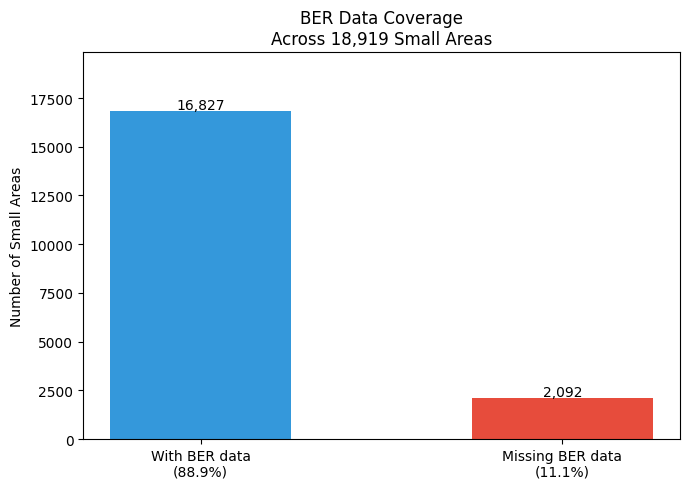

Saved: eda_03_ber_coverage.png


In [11]:
# Cell: EDA Graph 3 — BER Coverage
fig, ax = plt.subplots(figsize=(7, 5))
coverage_vals = [
    gdf_merged['property_count'].notna().sum(),
    gdf_merged['property_count'].isna().sum()
]
coverage_labels = [
    f'With BER data\n({coverage_vals[0]/len(gdf_merged)*100:.1f}%)',
    f'Missing BER data\n({coverage_vals[1]/len(gdf_merged)*100:.1f}%)'
]
bars2 = ax.bar(coverage_labels, coverage_vals,
               color=['#3498db', '#e74c3c'], edgecolor='none', width=0.5)
ax.set_title('BER Data Coverage\nAcross 18,919 Small Areas', fontsize=12)
ax.set_ylabel('Number of Small Areas')
ax.set_ylim(0, max(coverage_vals) * 1.18)
for bar, v in zip(bars2, coverage_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100,
            f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_03_ber_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_03_ber_coverage.png')